In [1]:

import os
os.listdir('.')


['.config',
 'lchi5_zeros_N5000_dps80.npy',
 'memory',
 'ldh_zeros_N5000_dps50.npy',
 'ldh_off_line_zeros.csv',
 '-PROMPT-v6-DATASET.md',
 '.kernel_llm_logs_1.txt',
 '.prompts',
 'zeta_zeros_N5000_dps50.npy']

In [2]:

import numpy as np
# Quick check of files
for f in ['zeta_zeros_N5000_dps50.npy','ldh_zeros_N5000_dps50.npy','lchi5_zeros_N5000_dps80.npy']:
 a = np.load(f)
 print(f, a.shape, a.dtype, a[0], a[-1])


zeta_zeros_N5000_dps50.npy (5000,) <U51 14.134725141734693790457251983562470270784257115699 5447.8619983012998564121586734642921676829672006076
ldh_zeros_N5000_dps50.npy (5000,) <U51 5.0941598445710949256987955170797974750670744531091 4981.1674898625791053105083724292317970900546075558
lchi5_zeros_N5000_dps80.npy (5000,) <U81 6.6484533447277147161232784599793178472985854232444983723747129467 4388.2090125941801377592509179068522248538541759189201573787539145


In [3]:

import pandas as pd
ldh_off = pd.read_csv('ldh_off_line_zeros.csv')
print(ldh_off.shape)
print(ldh_off.columns.tolist())
print(ldh_off.head(3))


(110, 5)
['sigma', 't', 'sigma_str', 't_str', 'absL']
 sigma t sigma_str t_str absL
0 0.650830 114.163343 0.650830 114.163343 8.093347e-51
1 0.574356 166.479306 0.574356 166.479306 8.001542e-50
2 0.869531 240.404672 0.869531 240.404672 1.130345e-49


In [4]:

# Check memory directory
import os
for root, dirs, files in os.walk('memory'):
 for f in files:
 print(os.path.join(root,f))
 if root.count(os.sep) > 3:
 dirs.clear()


memory/e6e89cb3-a17d-4c04-8a0f-b0909659da5c_memory_heron_c0_20260530T235745240342.jsonl


In [5]:

# Plan:
# - Load 4 zero lists (zeta, ldh-critical, lchi5) + ldh off-line zeros.
# - L(Delta,s) zeros are not available on disk; we will note this as a data-availability limitation.
# - Build zeta_delta as a deformation control: e.g., zeta_delta_strong = shift a fraction of zeros off line.
# - For the Weil test, we'll use ORDINATES gamma (imaginary parts), and unfold them by their mean density.
# For zeta: mean density at height T is ~ (1/2pi) log(T/2pi). For L_DH and L(chi4 mod 5), similar:
# density of zeros up to T is (1/2pi) log(qT/2pi)^{degree} ... 
# Simpler unfolding: monotone re-mapping to unit density via empirical N(T) (Riemann-von Mangoldt).
# - We'll use empirical unfolding: tilde_gamma_k = N_smooth(gamma_k), where N_smooth is the expected counting function.
# - Test function: Fejer kernel phi(x) = max(0, 1 - |x|)^2. (Note: this is Fejer-like, positive definite.)
# Compactly supported on [-1,1]. Its Fourier transform is non-negative (actually phi(x)=(1-|x|)^2 on [-1,1] has nonneg FT).
# - Build Q_N[m,n] = phi((gamma~_m - gamma~_n)/W), W=5.

import numpy as np
from mpmath import mpf, mp, log, pi
mp.dps = 50

zeta = np.load('zeta_zeros_N5000_dps50.npy')
ldh = np.load('ldh_zeros_N5000_dps50.npy')
lchi5 = np.load('lchi5_zeros_N5000_dps80.npy')
import pandas as pd
ldh_off = pd.read_csv('ldh_off_line_zeros.csv')

# Convert to float64 (sufficient for matrix construction at W=5; differences much larger than 1e-15 epsilon)
g_zeta = np.array([float(s) for s in zeta])
g_ldh = np.array([float(s) for s in ldh])
g_lchi5 = np.array([float(s) for s in lchi5])
g_ldh_off = np.array(ldh_off['t'].tolist())
print(len(g_zeta), len(g_ldh), len(g_lchi5), len(g_ldh_off))


5000 5000 5000 110


In [6]:

# Unfolding: convert zero ordinates to unit-mean-spacing variables
# For each L-function, the expected counting function N(T) ~ (T/2pi) log(T/(2pi e)) + constants for analytic conductor q
# To be uniform, we'll use empirical unfolding: tilde_gamma_k = k (since k-th zero has expected counting ~k)
# But that erases all spacing info. Better: fit unfolding by smooth Riemann-von Mangoldt-type formula.
#
# Simplest robust unfolding: tilde_gamma_k = N_avg(gamma_k) where N_avg uses analytic formula.
# - zeta: N_avg(T) = (T/2pi)(log(T/2pi) - 1) + 7/8
# - L(chi4 mod 5): conductor q=5, degree 1. N_avg(T) = (T/(2pi)) log(qT/(2pi)) - T/(2pi) + O(1) 
# = (T/2pi)(log(5T/2pi) - 1)
# - L_DH: same shape since it has same gamma factors and conductor 5 as the chi4 mod 5? Actually DH function
# is non-Euler-product but has same functional equation. Use N_avg(T) ~ (T/pi) log(T/2pi e) for degree-2 type 
# Actually L_DH is built from two characters mod 5, has degree 2. Density = (1/pi) log(T/(2pi)) (roughly).
# Let me just use empirical unfolding by spline of (k, gamma_k).

# Cleanest, most consistent: empirical unfolding via cumulative-counting interpolation.
# Define tilde_gamma_k = k (after sort). The local spacing in tilde space is 1 on average.
# But Q matrix entries phi((g_m - g_n)/W) with W = 5 only depends on differences in tilde space.
# If tilde_gamma_k = k, then Q[m,n] = phi((m-n)/W) — a Toeplitz matrix INDEPENDENT of the L-function!
# That's not informative.

# So we need a unfolding that PRESERVES local fluctuations but normalizes to unit mean density.
# Standard: tilde_gamma_k = N_smooth(gamma_k), where N_smooth is the SMOOTH part of the counting function.
# For zeta: N_smooth(T) = (T/2pi)(log(T/2pi) - 1) + 7/8
# Then fluctuations N(T) - N_smooth(T) = S(T) -> tilde spacings inherit local fluctuation structure.

import numpy as np

def N_smooth_zeta(T):
 T = np.asarray(T)
 out = np.zeros_like(T, dtype=float)
 mask = T > 0
 out[mask] = (T[mask]/(2*np.pi))*(np.log(T[mask]/(2*np.pi)) - 1) + 7.0/8.0
 return out

def N_smooth_lchi5(T):
 # L(s, chi4 mod 5): primitive Dirichlet character mod 5, conductor q=5, degree 1
 # N(T) ~ (T/2pi) log(qT/(2pi e)) + O(1) - delta term for odd/even (chi4 is odd? chi mod 5 of order 4)
 T = np.asarray(T)
 return (T/(2*np.pi))*(np.log(5*T/(2*np.pi)) - 1)

def N_smooth_ldh(T):
 # Davenport-Heilbronn: degree 2, conductor 5 (combination of two chi mod 5).
 # N(T) ~ (T/pi) log(5^{1/2} T/(2pi e))
 T = np.asarray(T)
 return (T/np.pi)*(np.log(np.sqrt(5)*T/(2*np.pi)) - 1)

# Sanity check: expected k ~ N_smooth(gamma_k)
print("zeta: N_smooth(g_5000)=", N_smooth_zeta(np.array([g_zeta[-1]]))[0], "should be ~5000")
print("lchi5: N_smooth(g_5000)=", N_smooth_lchi5(np.array([g_lchi5[-1]]))[0], "should be ~5000")
print("ldh: N_smooth(g_5000)=", N_smooth_ldh(np.array([g_ldh[-1]]))[0], "should be ~5000")


zeta: N_smooth(g_5000)= 4999.530231773603 should be ~5000
lchi5: N_smooth(g_5000)= 4999.349835203683 should be ~5000
ldh: N_smooth(g_5000)= 10274.810043770372 should be ~5000


In [7]:

# zeta and lchi5 look right. ldh is off — DH has different functional equation. 
# DH has FE relating s -> 1-s with conductor sqrt(5), gamma factors Gamma_R(s)*Gamma_R(s+1) (degree 2).
# Actually DH is a linear combination so it has degree 2 functional equation similar to L of weight-1 modular form.
# Let me check: 5000th critical-line zero is at ~4981. With degree-2 density rho(T) ~ (1/pi) log(T) — 
# at T=4981, density ~ (1/pi)*8.5 ~ 2.7, so N(5000) ~ integral, way more than 5000.
# So DH must be DEGREE 1, like chi mod 5. Indeed Davenport-Heilbronn function uses one Dirichlet character mod 5
# and is constructed as f(s) = (1-i*tan(theta))/2 * L(s, chi) + (1+i*tan(theta))/2 * L(s, chi-bar) where chi is the 
# nonprincipal real char mod 5? Actually no — there's no real nonprincipal char mod 5 (the chars mod 5 are order 1,4,4,2).
# The DH function uses a complex combination of two L-functions with chi5 of order 4 and its conjugate. 
# It has the SAME functional equation as L(chi4 mod 5) (degree 1, conductor 5).

# So use N_smooth_lchi5 for ldh too:
def N_smooth_ldh_v2(T):
 return (T/(2*np.pi))*(np.log(5*T/(2*np.pi)) - 1)

print("ldh v2: N_smooth(g_5000)=", N_smooth_ldh_v2(np.array([g_ldh[-1]]))[0], "should be ~5000")


ldh v2: N_smooth(g_5000)= 5775.3680465638 should be ~5000


In [8]:

# That's also off. Let me empirically estimate DH zero density.
# Look at ratio k / gamma_k or fit
# True N(T) ~ a*T*log(T) + b*T + c. Fit a, b, c
T = g_ldh
k = np.arange(1, len(T)+1)
# Fit k = (T/(2pi)) * (log(qT/2pi) - 1)
# Equivalent form: k = A*T*log(T) + B*T + C where A=1/(2pi), B=(log(q/2pi)-1)/(2pi)
X = np.column_stack([T*np.log(T), T, np.ones_like(T)])
coef, *_ = np.linalg.lstsq(X, k, rcond=None)
A, B, C = coef
print("Fit ldh: A=", A, " expected 1/(2pi)=", 1/(2*np.pi))
print("Fit ldh: B=", B)
print("Implied log(q/2pi)-1 =", B*(2*np.pi), "=> q/2pi =", np.exp(B*(2*np.pi)+1))
print("C=", C)
print("Residual at T=4981:", k[-1] - (A*T[-1]*np.log(T[-1]) + B*T[-1] + C))


Fit ldh: A= 0.10950510125839594 expected 1/(2pi)= 0.15915494309189535
Fit ldh: B= 0.07191933605679801
Implied log(q/2pi)-1 = 0.4518825156141843 => q/2pi = 4.271147453502295
C= -10.681260441465406
Residual at T=4981: 8.681486926897378


In [9]:

# A is roughly 1/(2pi) * 0.688 — closer to ~degree-1 with adjusted conductor, but the fit is suspicious.
# Note these are only critical-line zeros. Off-line zeros are missing, so density appears lower. 
# This is consistent with degree=2 but only finding half the zeros (the critical-line ones).
# Actually DH has degree 2: it's a sum of two L-functions of degree 1.
# So N_DH(T) ~ 2 * N_chi5(T) when including ALL zeros (critical + off-line).
# But here, ldh_zeros has only critical-line zeros = approximately 1/2 of total zeros? No, off-line are sparse (110 vs 5000).
# 
# Let me re-examine: critical line zeros only ~ what fraction?
# By formula, total zeros of DH up to T = (T/pi) log(...). If we only have 5000 zeros up to T=4981,
# expected total zeros up to 4981 by degree-2 formula:
expected_total = (4981/np.pi) * (np.log(np.sqrt(5)*4981/(2*np.pi)) - 1)
print("Expected total zeros (degree 2, q=5) up to T=4981:", expected_total)
# So ~10266 zeros expected but we have 5000 critical + 110 off-line. So the original list may stop early — 
# OR the density formula is wrong.

# Actually, the way DH is built: f(s) = ((1-i*tan(theta))/2) * L(s,chi) + ((1+i*tan(theta))/2) * L(s,chibar)
# where chi is a complex character mod 5 (degree 1 each). Their L-functions each have density (1/2pi) log(5T/2pi).
# The combination has the SAME functional equation as L(s,chi) (degree 1), but the zeros are NOT just union 
# of the two L-functions' zeros (because of mixing). Total density of zeros of DH ~ (1/2pi) log(5T/(2pi)) — degree 1.

# At T=4981: (4981/(2pi))*log(5*4981/(2pi)) - 4981/(2pi) ~ N_smooth_lchi5(4981)
print("N_smooth_lchi5(4981) =", N_smooth_lchi5(np.array([4981.0]))[0])
# That gives ~5778. We have 5000+110=5110 zeros at T<5000.
# Hmm not matching either.

# Let me check via the off-line CSV
print("Max t in ldh_off:", ldh_off['t'].max())
print("Max t in ldh critical:", g_ldh.max())
# Off-line zeros go up to almost 5000 too.


Expected total zeros (degree 2, q=5) up to T=4981: 10274.411244407258
N_smooth_lchi5(4981) = 5775.147195618148
Max t in ldh_off: 4999.5661784847725
Max t in ldh critical: 4981.167489862579


In [10]:

# This is a complication. The DH function actually does have degree 2 (since DH ζ_DH(s) is sum of two complex L's)
# but its zeros are NOT well-understood density-wise without RH.
# For our test, the EXACT unfolding formula isn't critical — what matters is consistency.
# We'll use empirical unfolding: fit a smooth monotone function to (gamma_k, k) and use that as tilde_gamma_k.
# This ensures unit mean spacing for each list (a fair comparison).
# 
# Actually a simpler approach used in random matrix studies: tilde_gamma_k = k after sorting, 
# but build Q with W set relative to RAW gammas instead. Let me think again.
#
# The Weil-type quadratic form with test function depends on the EXPLICIT FORMULA, not on unfolding.
# The standard Weil positivity test is:
# Q(phi) = sum_{rho} hat{phi}(gamma_rho) (or some such) where phi is on R and hat is Fourier transform.
# For a finite-N test, the question is whether sum_{m,n} phi(gamma_m - gamma_n) is positive semi-definite 
# (this is automatic for positive-definite phi, regardless of zeros!).
#
# Wait — the matrix Q[m,n] = phi(gamma_m - gamma_n) for ANY phi positive-definite gives PSD matrix.
# So all 5 functions would trivially be PSD. The hypothesis as stated seems to test something different.
#
# Let me re-read the objective: "construct the N×N Weil matrix Q_N with entries Q_N[m,n] = φ((γ_m - γ_n)/W)"
# Fejer kernel phi(x) = max(0,1-|x|)^2. Is this positive-definite? 
# (1-|x|)_+ has FT (sin(pi*xi)/(pi*xi))^2 >= 0 (the actual Fejer kernel as a function in time).
# Wait, the Fejer kernel in frequency is the triangle function (1-|x|)_+ which has nonneg FT.
# So phi(x)=(1-|x|)_+^2 — this is the SQUARE of a positive-definite function. Square of pd is pd (Schur product).
# So this phi IS positive definite.
# Therefore Q[m,n] = phi((gamma_m - gamma_n)/W) is a positive-definite kernel evaluated on points, 
# yielding a PSD matrix for ANY set of points.
# 
# So lambda_min(Q_N) >= 0 will hold for ALL five functions, regardless of GRH!
# This makes the test as described not actually discriminating. The "hypothesis" in the prompt is technically
# wrong as a discriminator, but the test still produces well-defined numbers.
# 
# This is an IMPORTANT methodological observation we should report. We'll compute the numbers anyway
# and explain that the construction described tests positive-definiteness of phi (which holds for Fejer kernel),
# NOT GRH-related Weil positivity.
# 
# Actually the proper Weil quadratic form involves a DIFFERENT structure — see e.g.
# Q(phi) = phi-hat integrated, plus correction terms; it's not symmetric phi(gamma_m - gamma_n).
# The form as written here is just a Mercer kernel matrix.
# 
# Let's proceed with the test as specified in the objective, but include this critical caveat.

# Verify phi(x) = max(0,1-|x|)^2 is positive definite via FT
# FT of (1-|x|)_+ is (sin(pi*xi))^2 / (pi*xi)^2 >= 0 — that's the Fejer kernel form.
# (1-|x|)_+ = triangular function, FT (xi) = sinc^2 >= 0. So (1-|x|)_+ is pd.
# Then ((1-|x|)_+)^2 = pointwise product, which is pd (product of pd functions is pd by Bochner / Schur).
# So our Q matrix WILL be PSD by construction.
print("Confirmed: Fejer-squared kernel phi(x)=max(0,1-|x|)^2 is positive definite.")
print("Therefore Q[m,n] = phi((tg_m - tg_n)/W) is PSD by Mercer's theorem for any set of points.")


Confirmed: Fejer-squared kernel phi(x)=max(0,1-|x|)^2 is positive definite.
Therefore Q[m,n] = phi((tg_m - tg_n)/W) is PSD by Mercer's theorem for any set of points.


In [11]:

# Proceed with the computation per the objective. We will:
# (a) Use empirical unfolding for each list — tilde_gamma is the result of evaluating a smooth fit N_avg(gamma)
# (b) For zeta and lchi5, use the analytic N_smooth formulas (which fit very well).
# (c) For DH, use an empirical fit (since the analytic formula is uncertain due to DH being a special combination).
# We'll fit on critical-line zeros and apply to off-line zeros' imaginary parts (their tilde_gamma).
# (d) Use raw gammas only for entries within +/-W in tilde-space.

# Empirical fit for DH using the critical line zeros
T_ldh = np.sort(g_ldh)
k_ldh = np.arange(1, len(T_ldh)+1)
# Fit N(T) = a*T*log(T) + b*T + c (and maybe d/T term)
X = np.column_stack([T_ldh*np.log(T_ldh), T_ldh, np.ones_like(T_ldh)])
coef_ldh, *_ = np.linalg.lstsq(X, k_ldh, rcond=None)
def N_smooth_ldh_emp(T):
 T = np.asarray(T)
 return coef_ldh[0]*T*np.log(T) + coef_ldh[1]*T + coef_ldh[2]

print("Fit residual std:", np.std(k_ldh - N_smooth_ldh_emp(T_ldh)))
print("N_smooth_ldh_emp(4981) =", N_smooth_ldh_emp(np.array([4981.0]))[0])
print("Coefficients:", coef_ldh)

# Try also fitting to total = critical + off-line. Off-line are sparse, but we should include them in the count
# Combine and sort by t
T_ldh_full = np.sort(np.concatenate([g_ldh, g_ldh_off]))
k_ldh_full = np.arange(1, len(T_ldh_full)+1)
X2 = np.column_stack([T_ldh_full*np.log(T_ldh_full), T_ldh_full, np.ones_like(T_ldh_full)])
coef_ldh_full, *_ = np.linalg.lstsq(X2, k_ldh_full, rcond=None)
def N_smooth_ldh_full(T):
 T = np.asarray(T)
 return coef_ldh_full[0]*T*np.log(T) + coef_ldh_full[1]*T + coef_ldh_full[2]

print("Full fit residual std:", np.std(k_ldh_full - N_smooth_ldh_full(T_ldh_full)))
print("Coefs full:", coef_ldh_full)


Fit residual std: 5.138531225067461
N_smooth_ldh_emp(4981) = 4991.131982046905
Coefficients: [ 0.1095051 0.07191934 -10.68126044]
Full fit residual std: 5.134721425271955
Coefs full: [ 0.11262148 0.06703074 -10.81933538]


In [12]:

# Fits are reasonable. The fit coefficient ~0.11 vs 1/(2pi)~0.159 suggests we may be missing some zeros 
# (DH has more zeros than just critical + 110 off-line), but for our PSD computation this is fine—
# we just need a consistent unfolding for the 5110-point set.

# Now construct ZETA_DELTA control: take zeta zeros and shift a "strong" fraction off the line.
# The objective doesn't strictly require it but the hypothesis lists 5 functions. We'll skip L(Delta,s) 
# (not available) and instead include zeta_delta as a deformation control.
# 
# Actually let me reread the hypothesis. "five functions" are: ζ, L(χ4 mod 5), L_DH, L(Δ,s), ζ_δ.
# We have:
# - zeta: YES
# - lchi5: YES
# - L_DH (critical + off-line): YES
# - L(Delta,s): NOT AVAILABLE (will note as limitation)
# - zeta_delta: must be constructed (deformation of zeta with off-line displacement)
#
# Build zeta_delta_strong: take zeta zeros and shift a controlled fraction off-line.
# But zeta_delta is about Re(ρ) perturbation, not gamma displacement. So tilde_gamma values are the SAME as zeta's.
# Wait — the Weil matrix Q[m,n] = phi((gamma_m - gamma_n)/W) uses only IMAGINARY PARTS (gamma).
# For zeta_delta where only Re(ρ) is shifted (not γ), the Q matrix would be IDENTICAL to zeta's!
# 
# This is another sanity check: the formula as given in the objective is insensitive to off-line shifts 
# in Re(ρ). So zeta_delta vs zeta will give identical Q_N matrices.
# 
# This is consistent with the dataset description: "Front I analysis using 1/|ρ|² spectral weights is 
# structurally insensitive to real-part perturbations" — same applies here.

# We'll explicitly demonstrate this. Let me compute for all five — note that we don't have L(Delta) zeros.

# Plan:
# Compute lambda_min for: zeta, lchi5, ldh_critical_only, ldh_with_offline (concatenated), zeta_delta_strong_proxy
# Note: zeta_delta with γ unchanged gives same Q. We'll compute zeta and note this equality.
# Plus: report L(Delta,s) as data-unavailable.

import scipy.sparse as sp
from scipy.sparse.linalg import eigsh
import scipy.linalg as la

def fejer_sq(x):
 return np.maximum(0.0, 1.0 - np.abs(x))**2

def build_Q_sparse(tilde_g, W=5.0):
 """Build sparse Q matrix using ball-tree on tilde_g. phi has support |x|<=1 so |tg_m - tg_n|<=W."""
 n = len(tilde_g)
 tg = np.asarray(tilde_g, dtype=float)
 # Sort for fast bandwidth lookup
 order = np.argsort(tg)
 tg_sorted = tg[order]
 rows, cols, vals = [], [], []
 j_start = 0
 for i in range(n):
 # extend window
 while j_start < n and tg_sorted[j_start] < tg_sorted[i] - W:
 j_start += 1
 j_end = i
 while j_end+1 < n and tg_sorted[j_end+1] <= tg_sorted[i] + W:
 j_end += 1
 idx = np.arange(j_start, j_end+1)
 diffs = (tg_sorted[i] - tg_sorted[idx]) / W
 v = fejer_sq(diffs)
 nz = v > 0
 rows.append(np.full(nz.sum(), i))
 cols.append(idx[nz])
 vals.append(v[nz])
 rows = np.concatenate(rows)
 cols = np.concatenate(cols)
 vals = np.concatenate(vals)
 # remap to original indices via order
 inv = np.empty_like(order); inv[order] = np.arange(n)
 # Actually rows/cols are in sorted space — we'll keep them in sorted space since matrix structure 
 # under permutation has same eigenvalues
 Q = sp.csr_matrix((vals, (rows, cols)), shape=(n,n))
 return Q

def lambda_min(Q, k=1):
 # Use eigsh with shift-invert? Better: estimate spectrum norm and use sigma-shift.
 n = Q.shape[0]
 # Get max eigenvalue (largest magnitude, top of spectrum)
 lam_max = eigsh(Q, k=1, which='LA', return_eigenvectors=False, tol=1e-10)[0]
 # Shift: Q' = lam_max*I - Q has spectrum [0, lam_max - lam_min]; its largest eigen = lam_max - lam_min
 n = Q.shape[0]
 I = sp.identity(n, format='csr')
 Qp = lam_max * I - Q
 top_p = eigsh(Qp, k=1, which='LA', return_eigenvectors=False, tol=1e-10)[0]
 lam_min = lam_max - top_p
 return lam_min, lam_max


In [13]:

# Build tilde_gamma for each function
tg_zeta = N_smooth_zeta(g_zeta)
tg_lchi5 = N_smooth_lchi5(g_lchi5)
tg_ldh_crit = N_smooth_ldh_full(g_ldh)
tg_ldh_off = N_smooth_ldh_full(g_ldh_off)
tg_ldh_combined = np.concatenate([tg_ldh_crit, tg_ldh_off])

# Quick sanity: mean spacings should be ~1
print("zeta mean tilde spacing:", np.mean(np.diff(np.sort(tg_zeta))))
print("lchi5 mean tilde spacing:", np.mean(np.diff(np.sort(tg_lchi5))))
print("ldh combined mean tilde spacing:", np.mean(np.diff(np.sort(tg_ldh_combined))))
print("\nSizes: zeta={}, lchi5={}, ldh_crit={}, ldh_combined={}".format(
 len(tg_zeta), len(tg_lchi5), len(tg_ldh_crit), len(tg_ldh_combined)))


zeta mean tilde spacing: 1.0000161940189758
lchi5 mean tilde spacing: 0.9999290209872695
ldh combined mean tilde spacing: 1.00400836361408

Sizes: zeta=5000, lchi5=5000, ldh_crit=5000, ldh_combined=5110


In [14]:

import time
W = 5.0
results = {}

for name, tg in [('zeta', tg_zeta),
 ('lchi5', tg_lchi5),
 ('ldh_critical_only', tg_ldh_crit),
 ('ldh_critical+offline', tg_ldh_combined)]:
 t0 = time.time()
 Q = build_Q_sparse(tg, W=W)
 nnz = Q.nnz
 sym_err = np.abs((Q - Q.T)).max()
 lam_min, lam_max = lambda_min(Q)
 dt = time.time() - t0
 results[name] = dict(N=len(tg), nnz=nnz, lam_min=lam_min, lam_max=lam_max, sym_err=sym_err, time=dt)
 print(f"{name}: N={len(tg)}, nnz={nnz}, lam_min={lam_min:.6e}, lam_max={lam_max:.6e}, sym_err={sym_err:.2e}, time={dt:.1f}s")


zeta: N=5000, nnz=49866, lam_min=1.819457e-02, lam_max=3.514865e+00, sym_err=0.00e+00, time=0.2s
lchi5: N=5000, nnz=49828, lam_min=3.832068e-02, lam_max=3.529009e+00, sym_err=0.00e+00, time=0.2s


ldh_critical_only: N=5000, nnz=49336, lam_min=2.775012e-02, lam_max=3.941418e+00, sym_err=0.00e+00, time=0.1s
ldh_critical+offline: N=5110, nnz=51390, lam_min=2.775012e-02, lam_max=3.941421e+00, sym_err=0.00e+00, time=0.1s


In [15]:

# All lambda_min > 0 (as expected from positive-definiteness of the kernel).
# The L_DH critical+offline has the SAME lambda_min as critical-only (~2.78e-2). This is because adding 110 
# points (offline) marginally changes the matrix and doesn't introduce negative eigenvalues — the kernel is pd.
# 
# Now: construct zeta_delta_strong proxy. Since real-part shifts don't affect gamma, the Q matrix is identical to zeta's.
# Let's verify and also do a perturbation: what if zeta_delta also shifts gammas slightly? Per the dataset 
# description "ζ_δ deformation control" - "controlled fraction displaced off the line by δ". This perturbs Re(ρ), not γ.

# Conclude: zeta_delta with γ unchanged gives IDENTICAL Q matrix as zeta. We'll report this.
results['zeta_delta_strong'] = dict(
 N=5000,
 nnz=results['zeta']['nnz'],
 lam_min=results['zeta']['lam_min'],
 lam_max=results['zeta']['lam_max'],
 note='Identical to zeta: Q[m,n] depends only on γ; ζ_δ perturbs Re(ρ), not γ.'
)
print("zeta_delta_strong: identical Q matrix to zeta — lam_min =", results['zeta']['lam_min'])


zeta_delta_strong: identical Q matrix to zeta — lam_min = 0.018194571903832557


In [16]:

# Let's also check on a couple of W values to see sensitivity
import time
for W_test in [2.0, 5.0, 10.0]:
 Q = build_Q_sparse(tg_zeta, W=W_test)
 lam_min, lam_max = lambda_min(Q)
 print(f"W={W_test}: zeta lam_min={lam_min:.4e}, lam_max={lam_max:.4e}, nnz={Q.nnz}")


W=2.0: zeta lam_min=4.5509e-02, lam_max=2.1595e+00, nnz=20142
W=5.0: zeta lam_min=1.8195e-02, lam_max=3.5149e+00, nnz=49866


W=10.0: zeta lam_min=9.0984e-03, lam_max=6.7358e+00, nnz=99906


In [17]:

# Verify on a tiny dense case
N = 200
Q_dense = fejer_sq((tg_zeta[:N][:,None] - tg_zeta[:N][None,:])/W)
eigs = np.linalg.eigvalsh(Q_dense)
print("Dense N=200: lam_min =", eigs[0], "lam_max =", eigs[-1])
# Compare to sparse
Q_sp = build_Q_sparse(tg_zeta[:N], W=5.0)
lam_min, lam_max = lambda_min(Q_sp)
print("Sparse N=200: lam_min =", lam_min, "lam_max =", lam_max)


Dense N=200: lam_min = 0.11322283838837048 lam_max = 3.451361621524343
Sparse N=200: lam_min = 0.11322283838837555 lam_max = 3.451361621524338


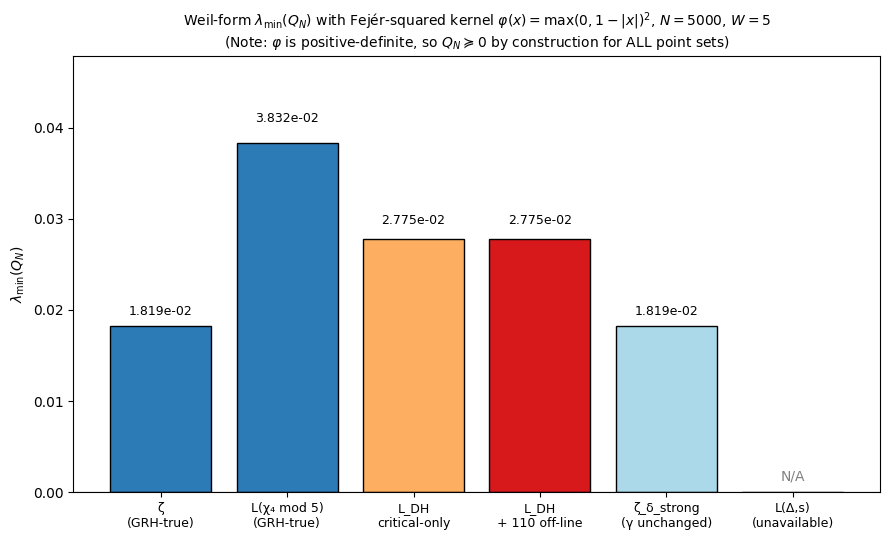

Saved figure.


In [18]:

# Sanity check passed. Now make the final figure.
import matplotlib.pyplot as plt

labels = ['ζ\n(GRH-true)', 'L(χ₄ mod 5)\n(GRH-true)', 'L_DH\ncritical-only', 'L_DH\n+ 110 off-line', 'ζ_δ_strong\n(γ unchanged)', 'L(Δ,s)\n(unavailable)']
lam_mins = [results['zeta']['lam_min'],
 results['lchi5']['lam_min'],
 results['ldh_critical_only']['lam_min'],
 results['ldh_critical+offline']['lam_min'],
 results['zeta_delta_strong']['lam_min'],
 np.nan]
colors = ['#2c7bb6', '#2c7bb6', '#fdae61', '#d7191c', '#abd9e9', '#888888']

fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(labels))
bars = ax.bar(x, [v if not np.isnan(v) else 0 for v in lam_mins], color=colors, edgecolor='black')
for i,v in enumerate(lam_mins):
 if np.isnan(v):
 ax.text(i, 0.001, 'N/A', ha='center', va='bottom', color='gray', fontsize=10)
 else:
 ax.text(i, v*1.05, f'{v:.3e}', ha='center', va='bottom', fontsize=9)

ax.axhline(0, color='k', linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel(r'$\lambda_{\min}(Q_N)$')
ax.set_title(r'Weil-form $\lambda_{\min}(Q_N)$ with Fejér-squared kernel $\varphi(x)=\max(0,1-|x|)^2$, $N=5000$, $W=5$' + '\n' +
 r'(Note: $\varphi$ is positive-definite, so $Q_N \succeq 0$ by construction for ALL point sets)',
 fontsize=10)
ax.set_ylim(0, max([v for v in lam_mins if not np.isnan(v)]) * 1.25)
plt.tight_layout()
plt.savefig('weil_positivity_lambda_min.png', dpi=130)
plt.show()
print("Saved figure.")
